# 06b — Mitigated Few-Shot Fine-Tuning

learning rate was so low the model barely adapted, scoring *below* the naive Arm 1 (NB05)
on both domains. This version gives the encoder real adaptation capacity while keeping the
gradual-unfreeze + warmup cushion that protects against catastrophic forgetting.

| Param | NB06 (v1) | NB06b (this) |
|---|---|---|
| `ENCODER_LEARNING_RATE` | 5e-6 | **2e-5** |
| `FREEZE_EPOCHS` | 2 | **1** |
| `UNFREEZE_EPOCHS` | 6 | **7** (total still 8) |
| `HEAD_LEARNING_RATE` | 5e-5 | 5e-5 (unchanged) |

Outputs are written to **`results/mitigated_retuned/`**, so NB06's original results in
`results/mitigated/` are left intact for a side-by-side comparison. It still reads NB05's
results for the three-way (zero-shot vs naive vs retuned) comparison.


# 06 — Mitigated Few-Shot Fine-Tuning


| Dataset | Zero-shot boundary F1 (NB04) | Few-shot boundary F1 @50/100/200 (NB05) |
|---|---|---|
| WNUT-17 | **0.610** | 0.444 / 0.508 / 0.565 — *never recovers to the zero-shot level* |
| SciERC  | 0.068 | 0.419 / 0.542 / 0.624 — clear win |

On WNUT-17, naive fine-tuning on 50–200 sentences made entity-**boundary** detection worse
than doing nothing, across all three seeds at every budget. That's the signature of
**catastrophic forgetting**: the tiny target-domain fine-tuning signal overwrites the general
"is this span an entity" knowledge the encoder picked up from the much larger CoNLL-2003
training set, in exchange for learning WNUT-17's specific label types.

**What this notebook changes, and why:**

1. **Lower, differential learning rates.** The encoder (already well-initialized) gets a much
   smaller learning rate than the freshly-initialized classification head, instead of both
   being updated at the same `2e-5`.
2. **Gradual unfreezing.** Phase 1 trains *only* the new classification head with the encoder
   frozen, so the head isn't pushing huge, poorly-calibrated gradients back through the encoder
   from step one. Phase 2 unfreezes the encoder and continues training both, at the lower
   encoder learning rate.
3. **Warmup.** A linear warmup ratio is added (absent in Notebook 05), which further smooths
   out the first, most destructive updates.
4. **Selection metric.** The best checkpoint is chosen using a **combined** metric
   (`(typed_f1 + boundary_f1) / 2`) instead of `typed_f1` alone, so checkpoint selection can no
   longer pick a model that traded away boundary detection for typed accuracy.


In [1]:

!rm -rf /content/drive/MyDrive/AAI590/data/processed/results/mitigated_retuned
!pip -q install "transformers==4.44.2" "datasets==2.19.2" "seqeval==1.2.2" "accelerate>=0.26.0" pandas matplotlib

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. In Colab, select Runtime > Change runtime type > GPU.")


GPU available: True
GPU: Tesla T4


## Quiet mode

The cells below intentionally trigger a few harmless warnings from `transformers` and `huggingface_hub` (e.g. a note that no `HF_TOKEN` is set, or that a randomly-initialized head is expected -- classifier head here, or MLM head in Notebook 07). This cell silences those specific, known-benign warnings so the notebook output stays readable, without hiding real errors.

In [2]:
import os
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")
warnings.filterwarnings("ignore", message=".*newly initialized.*")

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


## Step 1 — Mount Drive and configure the experiment

Same directory layout as Notebook 05. Results are written to a separate
`results/mitigated` folder so Notebook 05's outputs are untouched.

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from datasets import load_from_disk
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report
from transformers import (
    AutoConfig,
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

PROCESSED = Path("/content/drive/MyDrive/AAI590/data/processed")
TOKENIZED_DIR = PROCESSED / "tokenized"
LABELS_DIR = PROCESSED / "label_maps"
MODELS_DIR = PROCESSED / "models"
RESULTS_DIR = PROCESSED / "results"
BASELINE_DIR = MODELS_DIR / "baseline_conll2003"

NAIVE_FEWSHOT_RESULTS_DIR = RESULTS_DIR / "fewshot_v2"
MITIGATED_RESULTS_DIR = RESULTS_DIR / "mitigated_retuned"
MITIGATED_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


TARGET_DATASETS = ["wnut17", "scierc"]
BUDGETS = [50, 100, 200]
SEEDS = [13, 42, 101]

# --- Mitigated fine-tuning settings ---
HEAD_LEARNING_RATE = 5e-5
ENCODER_LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1

FREEZE_EPOCHS = 1                 # Phase 1: encoder frozen, only the head trains -- constant across budgets
# Budget-scaled total epochs (freeze + unfreeze). NOTE: budget=50 uses fewer epochs
# here (10) than in NB05 (20) -- at 50 examples, 20 epochs through the phase-1/phase-2
# transition produced catastrophic divergence in 2 of 3 seeds on SciERC (validation
# combined_f1 ~0.04-0.06 vs ~0.43 for the surviving seed). Trading some of the
# low-budget training-length benefit for stability at this specific budget.
TOTAL_EPOCHS_BY_BUDGET = {50: 10, 100: 12, 200: 8}
# UNFREEZE_EPOCHS is now computed per-run inside run_mitigated_experiment as
# TOTAL_EPOCHS_BY_BUDGET[budget] - FREEZE_EPOCHS.
MAX_GRAD_NORM = 1.0                # explicit clipping during Phase 2 (encoder unfrozen)

TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2       # applied during Phase 2 only

# Saving all 18 models can consume substantial Drive space.
SAVE_ALL_MODELS = False

required_paths = [TOKENIZED_DIR, LABELS_DIR, BASELINE_DIR]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required path: {path}\n"
            "Run Notebooks 03 and 04 successfully before running Notebook 06."
        )

print("Processed directory:", PROCESSED)
print("Baseline model:", BASELINE_DIR)
print("Mitigated results directory:", MITIGATED_RESULTS_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processed directory: /content/drive/MyDrive/AAI590/data/processed
Baseline model: /content/drive/MyDrive/AAI590/data/processed/models/baseline_conll2003
Mitigated results directory: /content/drive/MyDrive/AAI590/data/processed/results/mitigated_retuned


## Step 2 — Load the baseline model and tokenizer
Each target dataset
still gets its own freshly-initialized classification head.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(str(BASELINE_DIR), clean_up_tokenization_spaces=True)
baseline_model = AutoModelForTokenClassification.from_pretrained(str(BASELINE_DIR))

print("Baseline architecture:", baseline_model.config.model_type)
print("Baseline output labels:", baseline_model.config.num_labels)
print("Baseline encoder loaded successfully.")


Baseline architecture: bert
Baseline output labels: 8
Baseline encoder loaded successfully.


## Step 3 — Helper functions

Three additions:

- `combined_f1` in the metrics dict, used for checkpoint selection.
- `freeze_encoder` / `unfreeze_encoder` for the two training phases.
- `build_two_group_optimizer`, which gives the head and the encoder different learning rates
  (standard AdamW, but with separate parameter groups instead of one global `learning_rate`).

In [5]:
def load_label_map(dataset_name):
    path = LABELS_DIR / f"{dataset_name}_label_map.json"
    with open(path) as f:
        mapping = json.load(f)

    label2id = {str(k): int(v) for k, v in mapping["label2id"].items()}
    id2label = {int(k): str(v) for k, v in mapping["id2label"].items()}
    return label2id, id2label


def collapse_to_boundary(tag):
    '''Convert a typed BIO tag to O, B-ENT, or I-ENT.'''
    if tag == "O":
        return "O"
    if tag.startswith("B-"):
        return "B-ENT"
    if tag.startswith("I-"):
        return "I-ENT"
    raise ValueError(f"Unexpected BIO tag: {tag}")


def decode_predictions(eval_pred, id2label):
    '''Decode non-ignored labels and predictions into BIO tag sequences.'''
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_tags = []
    predicted_tags = []

    for pred_row, label_row in zip(predictions, labels):
        sentence_true = []
        sentence_pred = []

        for pred_id, label_id in zip(pred_row, label_row):
            if label_id == -100:
                continue

            sentence_true.append(id2label[int(label_id)])
            sentence_pred.append(id2label[int(pred_id)])

        true_tags.append(sentence_true)
        predicted_tags.append(sentence_pred)

    return true_tags, predicted_tags


def build_compute_metrics(id2label):
    '''Create a Trainer metric function for a target dataset's label map.

    Adds `combined_f1` = mean(typed_f1, boundary_f1) relative to Notebook 05, so
    checkpoint selection can't silently trade boundary detection for typed accuracy.
    '''
    def compute_metrics(eval_pred):
        true_tags, predicted_tags = decode_predictions(eval_pred, id2label)

        true_boundary = [
            [collapse_to_boundary(tag) for tag in sentence]
            for sentence in true_tags
        ]
        predicted_boundary = [
            [collapse_to_boundary(tag) for tag in sentence]
            for sentence in predicted_tags
        ]

        typed_f1 = f1_score(true_tags, predicted_tags)
        boundary_f1 = f1_score(true_boundary, predicted_boundary)

        return {
            "typed_precision": precision_score(true_tags, predicted_tags),
            "typed_recall": recall_score(true_tags, predicted_tags),
            "typed_f1": typed_f1,
            "boundary_precision": precision_score(true_boundary, predicted_boundary),
            "boundary_recall": recall_score(true_boundary, predicted_boundary),
            "boundary_f1": boundary_f1,
            "combined_f1": (typed_f1 + boundary_f1) / 2.0,
        }

    return compute_metrics


def load_target_datasets(dataset_name, budget, seed):
    fewshot_path = (
        TOKENIZED_DIR / "fewshot" / dataset_name /
        f"budget{budget}_seed{seed}"
    )
    validation_path = TOKENIZED_DIR / dataset_name / "validation"
    test_path = TOKENIZED_DIR / dataset_name / "test"

    for path in [fewshot_path, validation_path, test_path]:
        if not path.exists():
            raise FileNotFoundError(
                f"Missing tokenized dataset: {path}\n"
                "Re-run Notebook 03 to create all tokenized few-shot splits."
            )

    return (
        load_from_disk(str(fewshot_path)),
        load_from_disk(str(validation_path)),
        load_from_disk(str(test_path)),
    )


def create_target_model(dataset_name):
    '''Create a target-label model initialized with the CoNLL-trained encoder.'''
    label2id, id2label = load_label_map(dataset_name)

    config = AutoConfig.from_pretrained(
        "bert-base-cased",
        num_labels=len(id2label),
        label2id=label2id,
        id2label=id2label,
    )

    target_model = AutoModelForTokenClassification.from_pretrained(
        "bert-base-cased",
        config=config,
        ignore_mismatched_sizes=True,
    )

    # Transfer the source-domain representation learned in Notebook 04.
    target_model.base_model.load_state_dict(
        baseline_model.base_model.state_dict(),
        strict=True,
    )

    return target_model, label2id, id2label


def freeze_encoder(model):
    for param in model.base_model.parameters():
        param.requires_grad = False


def unfreeze_encoder(model):
    for param in model.base_model.parameters():
        param.requires_grad = True


def build_two_group_optimizer(model, encoder_lr, head_lr, weight_decay=0.01):
    '''AdamW with separate learning rates for the classification head vs. the encoder,
    preserving the usual no-weight-decay treatment for biases and LayerNorm weights.'''
    no_decay = ["bias", "LayerNorm.weight"]

    head_decay, head_no_decay = [], []
    encoder_decay, encoder_no_decay = [], []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        is_head = name.startswith("classifier")
        is_no_decay = any(nd in name for nd in no_decay)

        if is_head:
            (head_no_decay if is_no_decay else head_decay).append(param)
        else:
            (encoder_no_decay if is_no_decay else encoder_decay).append(param)

    groups = [
        {"params": head_decay, "lr": head_lr, "weight_decay": weight_decay},
        {"params": head_no_decay, "lr": head_lr, "weight_decay": 0.0},
        {"params": encoder_decay, "lr": encoder_lr, "weight_decay": weight_decay},
        {"params": encoder_no_decay, "lr": encoder_lr, "weight_decay": 0.0},
    ]
    groups = [g for g in groups if len(g["params"]) > 0]
    return torch.optim.AdamW(groups)


def cleanup_memory(*objects):
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Step 4 — Sanity-check all required inputs

Catches missing tokenized splits before starting a long run.

In [6]:
input_rows = []

for dataset_name in TARGET_DATASETS:
    label2id, id2label = load_label_map(dataset_name)

    for split in ["validation", "test"]:
        path = TOKENIZED_DIR / dataset_name / split
        input_rows.append({
            "dataset": dataset_name,
            "split": split,
            "budget": None,
            "seed": None,
            "exists": path.exists(),
            "path": str(path),
            "num_labels": len(id2label),
        })

    for budget in BUDGETS:
        for seed in SEEDS:
            path = (
                TOKENIZED_DIR / "fewshot" / dataset_name /
                f"budget{budget}_seed{seed}"
            )
            input_rows.append({
                "dataset": dataset_name,
                "split": "fewshot_train",
                "budget": budget,
                "seed": seed,
                "exists": path.exists(),
                "path": str(path),
                "num_labels": len(id2label),
            })

input_check_df = pd.DataFrame(input_rows)
display(input_check_df)

missing = input_check_df.loc[~input_check_df["exists"]]
if not missing.empty:
    raise FileNotFoundError(
        "Some required inputs are missing. Re-run Notebook 03.\n" +
        "\n".join(missing["path"].tolist())
    )

print("All required inputs are available.")


,dataset,split,budget,seed,exists,path,num_labels
0,wnut17,validation,NaN,NaN,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
1,wnut17,test,NaN,NaN,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
2,wnut17,fewshot_train,50.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
3,wnut17,fewshot_train,50.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
4,wnut17,fewshot_train,50.0,101.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
5,wnut17,fewshot_train,100.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
6,wnut17,fewshot_train,100.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
7,wnut17,fewshot_train,100.0,101.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
8,wnut17,fewshot_train,200.0,13.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13
9,wnut17,fewshot_train,200.0,42.0,True,/content/drive/MyDrive/AAI590/data/processed/t...,13


All required inputs are available.


## Step 5 — Two-phase mitigated training

**Phase 1 (head warm-start):** the encoder is frozen; only the new classification head trains,
for `FREEZE_EPOCHS` epochs at `HEAD_LEARNING_RATE`. This gives the head a reasonable starting
point before any gradient reaches the encoder, instead of the encoder absorbing large,
poorly-calibrated gradients from a randomly-initialized head from step one.

**Phase 2 (full fine-tune, differential LR):** the encoder is unfrozen. Both the head and the
encoder train together for up to `UNFREEZE_EPOCHS` epochs, but through
`build_two_group_optimizer` the encoder moves at `ENCODER_LEARNING_RATE` (much slower) while the
head continues at `HEAD_LEARNING_RATE`. Warmup is applied, and early stopping now watches
`combined_f1` rather than `typed_f1` alone. The checkpoint with the best `combined_f1` on the
validation set is what gets evaluated on the held-out test set.

In [7]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)


def run_mitigated_experiment(dataset_name, budget, seed):
    print("=" * 80)
    print(f"[MITIGATED] Dataset={dataset_name} | Budget={budget} | Seed={seed}")
    print("=" * 80)

    set_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    train_ds, validation_ds, test_ds = load_target_datasets(dataset_name, budget, seed)
    model, label2id, id2label = create_target_model(dataset_name)
    compute_metrics = build_compute_metrics(id2label)
    unfreeze_epochs = TOTAL_EPOCHS_BY_BUDGET[budget] - FREEZE_EPOCHS
    import time as _time
    _t0 = _time.time()

    run_name = f"{dataset_name}_budget{budget}_seed{seed}"
    checkpoint_dir = Path("/content/mitigated_checkpoints") / run_name

    # ---------------- Phase 1: freeze encoder, warm-start the head ----------------
    freeze_encoder(model)

    phase1_args = TrainingArguments(
        output_dir=str(checkpoint_dir / "phase1"),
        eval_strategy="no",
        save_strategy="no",
        logging_strategy="epoch",
        num_train_epochs=FREEZE_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        learning_rate=HEAD_LEARNING_RATE,  # only the head has grads, so this applies to it
        report_to="none",
        seed=seed,
        data_seed=seed,
    )

    phase1_trainer = Trainer(
        model=model,
        args=phase1_args,
        train_dataset=train_ds,
        eval_dataset=validation_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    phase1_trainer.train()

    # ---------------- Phase 2: unfreeze, differential LR, early stopping ----------------
    unfreeze_encoder(model)
    optimizer = build_two_group_optimizer(
        model,
        encoder_lr=ENCODER_LEARNING_RATE,
        head_lr=HEAD_LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    phase2_args = TrainingArguments(
        output_dir=str(checkpoint_dir / "phase2"),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        num_train_epochs=unfreeze_epochs,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        learning_rate=ENCODER_LEARNING_RATE,
        load_best_model_at_end=True,
        metric_for_best_model="eval_combined_f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        seed=seed,
        data_seed=seed,
        max_grad_norm=MAX_GRAD_NORM,
    )

    phase2_trainer = Trainer(
        model=model,
        args=phase2_args,
        train_dataset=train_ds,
        eval_dataset=validation_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        optimizers=(optimizer, None),  # None -> Trainer builds the default linear+warmup scheduler
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )
    train_output = phase2_trainer.train()
    train_seconds = _time.time() - _t0

    validation_metrics = phase2_trainer.evaluate(validation_ds)
    test_metrics = phase2_trainer.evaluate(test_ds, metric_key_prefix="test")


    _preds, _labels, _ = phase2_trainer.predict(test_ds)
    _preds = np.argmax(_preds, axis=2)
    _tt, _pp = [], []
    for _pr, _lr in zip(_preds, _labels):
        _st, _sp = [], []
        for _p, _l in zip(_pr, _lr):
            if _l == -100:
                continue
            _st.append(id2label[int(_l)]); _sp.append(id2label[int(_p)])
        _tt.append(_st); _pp.append(_sp)
    _rep = classification_report(_tt, _pp, output_dict=True, zero_division=0)
    per_type = {k: {"precision": float(v["precision"]), "recall": float(v["recall"]),
                    "f1": float(v["f1-score"]), "support": int(v["support"])}
                for k, v in _rep.items()
                if k not in ("micro avg", "macro avg", "weighted avg")}

    if SAVE_ALL_MODELS:
        model_output_dir = (
            MODELS_DIR / "mitigated" / dataset_name /
            f"budget{budget}_seed{seed}"
        )
        model_output_dir.mkdir(parents=True, exist_ok=True)
        phase2_trainer.save_model(str(model_output_dir))
        tokenizer.save_pretrained(str(model_output_dir))
        saved_model_path = str(model_output_dir)
    else:
        saved_model_path = None

    result = {
        "dataset": dataset_name,
        "budget": budget,
        "seed": seed,
        "num_train_sentences": len(train_ds),
        "num_epochs": TOTAL_EPOCHS_BY_BUDGET[budget],
        "best_checkpoint": phase2_trainer.state.best_model_checkpoint,
        "best_validation_metric": phase2_trainer.state.best_metric,
        "training_loss": train_output.training_loss,
        "validation_typed_f1": validation_metrics.get("eval_typed_f1"),
        "validation_boundary_f1": validation_metrics.get("eval_boundary_f1"),
        "validation_combined_f1": validation_metrics.get("eval_combined_f1"),
        "test_typed_precision": test_metrics.get("test_typed_precision"),
        "test_typed_recall": test_metrics.get("test_typed_recall"),
        "test_typed_f1": test_metrics.get("test_typed_f1"),
        "test_boundary_precision": test_metrics.get("test_boundary_precision"),
        "test_boundary_recall": test_metrics.get("test_boundary_recall"),
        "test_boundary_f1": test_metrics.get("test_boundary_f1"),
        "test_combined_f1": test_metrics.get("test_combined_f1"),
        "train_seconds": round(train_seconds, 1),
        "per_type": json.dumps(per_type),
        "saved_model_path": saved_model_path,
    }

    print("\nTest results (mitigated):")
    print(f"  Typed F1:    {result['test_typed_f1']:.4f}")
    print(f"  Boundary F1: {result['test_boundary_f1']:.4f}")

    cleanup_memory(phase1_trainer, phase2_trainer, optimizer, model, train_ds, validation_ds, test_ds)
    return result


## Step 6 — Run the complete experiment grid

Same 18 runs as Notebook 05 (2 datasets × 3 budgets × 3 seeds), so the two result sets line up
row for row.

In [8]:
RESULTS_CSV = MITIGATED_RESULTS_DIR / "mitigated_results.csv"
RESULTS_JSON = MITIGATED_RESULTS_DIR / "mitigated_results.json"

if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV)
    completed = {
        (row.dataset, int(row.budget), int(row.seed))
        for row in results_df.itertuples()
    }
    all_results = results_df.to_dict("records")
    print(f"Resuming from {len(all_results)} completed runs.")
else:
    completed = set()
    all_results = []

for dataset_name in TARGET_DATASETS:
    for budget in BUDGETS:
        for seed in SEEDS:
            key = (dataset_name, budget, seed)

            if key in completed:
                print("Skipping completed run:", key)
                continue

            result = run_mitigated_experiment(dataset_name, budget, seed)
            all_results.append(result)
            completed.add(key)

            results_df = pd.DataFrame(all_results).sort_values(["dataset", "budget", "seed"])
            results_df.to_csv(RESULTS_CSV, index=False)

            with open(RESULTS_JSON, "w") as f:
                json.dump(
                    results_df.replace({np.nan: None}).to_dict("records"),
                    f,
                    indent=2,
                    default=str,
                )

            print("Saved progress to:", RESULTS_CSV)

results_df = pd.DataFrame(all_results).sort_values(
    ["dataset", "budget", "seed"]
).reset_index(drop=True)

display(results_df)


[MITIGATED] Dataset=wnut17 | Budget=50 | Seed=13


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'loss': 3.3408, 'grad_norm': 17.710323333740234, 'learning_rate': 0.0, 'epoch': 1.0}
{'train_runtime': 1.1397, 'train_samples_per_second': 43.871, 'train_steps_per_second': 6.142, 'train_loss': 3.3407794407435825, 'epoch': 1.0}
{'loss': 2.8495, 'grad_norm': 22.15484619140625, 'learning_rate': 5e-05, 'epoch': 1.0}
{'eval_loss': 1.5838055610656738, 'eval_typed_precision': 0.019550342130987292, 'eval_typed_recall': 0.023923444976076555, 'eval_typed_f1': 0.021516944593867673, 'eval_boundary_precision': 0.42288049029622066, 'eval_boundary_recall': 0.49521531100478466, 'eval_boundary_f1': 0.456198347107438, 'eval_combined_f1': 0.23885764585065283, 'eval_runtime': 2.8598, 'eval_samples_per_second': 352.826, 'eval_steps_per_second': 11.19, 'epoch': 1.0}
{'loss': 0.8504, 'grad_norm': 3.538503646850586, 'learning_rate': 4.375e-05, 'epoch': 2.0}
{'eval_loss': 0.3813779652118683, 'eval_typed_precision': 0.35714285714285715, 'eval_typed_recall': 0.05980861244019139, 'eval_typed_f1': 0.102459016393

,dataset,budget,seed,num_train_sentences,num_epochs,best_checkpoint,best_validation_metric,training_loss,validation_typed_f1,validation_boundary_f1,...,test_typed_precision,test_typed_recall,test_typed_f1,test_boundary_precision,test_boundary_recall,test_boundary_f1,test_combined_f1,train_seconds,per_type,saved_model_path
0,scierc,50,13,50,10,/content/mitigated_checkpoints/scierc_budget50...,0.041108,1.717239,0.014315,0.067901,...,0.034091,0.007130,0.011794,0.184971,0.038050,0.063116,0.037455,39.4,"{""Generic"": {""precision"": 0.0, ""recall"": 0.0, ...",None
1,scierc,50,42,50,10,/content/mitigated_checkpoints/scierc_budget50...,0.333600,0.771513,0.198881,0.468320,...,0.156886,0.160428,0.158637,0.525386,0.424495,0.469582,0.314110,104.5,"{""Generic"": {""precision"": 1.0, ""recall"": 0.016...",None
2,scierc,50,101,50,10,/content/mitigated_checkpoints/scierc_budget50...,0.277774,0.948140,0.134884,0.420664,...,0.124870,0.142602,0.133148,0.424900,0.442331,0.433440,0.283294,83.2,"{""Generic"": {""precision"": 0.0, ""recall"": 0.0, ...",None
3,scierc,100,13,100,12,/content/mitigated_checkpoints/scierc_budget10...,0.429707,0.663400,0.304740,0.554673,...,0.257267,0.315508,0.283427,0.535117,0.570749,0.552359,0.417893,130.9,"{""Generic"": {""precision"": 0.5815217391304348, ...",None
4,scierc,100,42,100,12,/content/mitigated_checkpoints/scierc_budget10...,0.438731,0.734748,0.271186,0.606276,...,0.233347,0.335116,0.275122,0.575823,0.634364,0.603678,0.439400,71.3,"{""Generic"": {""precision"": 0.75, ""recall"": 0.32...",None
5,scierc,100,101,100,12,/content/mitigated_checkpoints/scierc_budget10...,0.427962,0.628097,0.292544,0.563380,...,0.270353,0.313725,0.290429,0.593750,0.553508,0.572923,0.431676,117.1,"{""Generic"": {""precision"": 0.625, ""recall"": 0.3...",None
6,scierc,200,13,200,8,/content/mitigated_checkpoints/scierc_budget20...,0.493198,0.655321,0.373211,0.613184,...,0.335543,0.390969,0.361142,0.608180,0.609988,0.609083,0.485112,99.2,"{""Generic"": {""precision"": 0.6384180790960452, ...",None
7,scierc,200,42,200,8,/content/mitigated_checkpoints/scierc_budget20...,0.502609,0.563136,0.396629,0.608589,...,0.318554,0.392751,0.351783,0.599305,0.615339,0.607216,0.479500,109.7,"{""Generic"": {""precision"": 0.6071428571428571, ...",None
8,scierc,200,101,200,8,/content/mitigated_checkpoints/scierc_budget20...,0.522361,0.622380,0.404722,0.640000,...,0.344162,0.402852,0.371202,0.622971,0.615933,0.619432,0.495317,91.5,"{""Generic"": {""precision"": 0.6863905325443787, ...",None
9,wnut17,50,13,50,10,/content/mitigated_checkpoints/wnut17_budget50...,0.472809,0.591479,0.419934,0.525684,...,0.365532,0.308619,0.334673,0.517660,0.434662,0.472544,0.403609,149.4,"{""corporation"": {""precision"": 0.1, ""recall"": 0...",None


## Step 7 — Aggregate results across seeds

In [9]:
metric_columns = [
    "test_typed_precision",
    "test_typed_recall",
    "test_typed_f1",
    "test_boundary_precision",
    "test_boundary_recall",
    "test_boundary_f1",
    "test_combined_f1",
]

summary_df = (
    results_df
    .groupby(["dataset", "budget"])[metric_columns]
    .agg(["mean", "std"])
    .reset_index()
)

summary_df.columns = [
    "_".join(str(part) for part in col if str(part))
    if isinstance(col, tuple) else col
    for col in summary_df.columns
]

summary_path = MITIGATED_RESULTS_DIR / "mitigated_summary_by_budget.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df.round(4))
print("Saved summary to:", summary_path)


,dataset,budget,test_typed_precision_mean,test_typed_precision_std,test_typed_recall_mean,test_typed_recall_std,test_typed_f1_mean,test_typed_f1_std,test_boundary_precision_mean,test_boundary_precision_std,test_boundary_recall_mean,test_boundary_recall_std,test_boundary_f1_mean,test_boundary_f1_std,test_combined_f1_mean,test_combined_f1_std
0,scierc,50,0.1053,0.0637,0.1034,0.0838,0.1012,0.0785,0.3784,0.1749,0.3016,0.2284,0.3220,0.2250,0.2116,0.1516
1,scierc,100,0.2537,0.0188,0.3214,0.0119,0.2830,0.0077,0.5682,0.0300,0.5862,0.0426,0.5763,0.0258,0.4297,0.0109
2,scierc,200,0.3328,0.0130,0.3955,0.0064,0.3614,0.0097,0.6102,0.0120,0.6138,0.0033,0.6119,0.0066,0.4866,0.0080
3,wnut17,50,0.3180,0.0412,0.2904,0.0247,0.3030,0.0289,0.4712,0.0416,0.4288,0.0206,0.4482,0.0217,0.3756,0.0253
4,wnut17,100,0.3771,0.0274,0.3729,0.0408,0.3749,0.0341,0.5453,0.0198,0.5332,0.0353,0.5391,0.0276,0.4570,0.0308
5,wnut17,200,0.3945,0.0043,0.4035,0.0259,0.3986,0.0107,0.5620,0.0157,0.5669,0.0233,0.5640,0.0053,0.4813,0.0075


Saved summary to: /content/drive/MyDrive/AAI590/data/processed/results/mitigated_retuned/mitigated_summary_by_budget.csv


## Step 8 — Three-way comparison: zero-shot vs. naive few-shot (NB05) vs. mitigated few-shot (NB06)



In [10]:
BASELINE_RESULTS_PATH = RESULTS_DIR / "baseline_results.json"
NAIVE_RESULTS_PATH = NAIVE_FEWSHOT_RESULTS_DIR / "fewshot_results.csv"

comparison_rows = []

# --- Zero-shot (Notebook 04) ---
if BASELINE_RESULTS_PATH.exists():
    with open(BASELINE_RESULTS_PATH) as f:
        baseline_results = json.load(f)
    zero_shot = baseline_results.get("zero_shot_cross_domain_boundary_f1", {})
    for dataset_name in TARGET_DATASETS:
        values = zero_shot.get(dataset_name)
        if values:
            comparison_rows.append({
                "dataset": dataset_name,
                "budget": 0,
                "method": "Zero-shot baseline",
                "boundary_f1_mean": values.get("f1"),
                "boundary_f1_std": 0.0,
            })
else:
    print("Notebook 04 baseline_results.json not found -- run Notebook 04 first.")

# --- Naive few-shot (Notebook 05) ---
if NAIVE_RESULTS_PATH.exists():
    naive_df = pd.read_csv(NAIVE_RESULTS_PATH)
    naive_boundary = (
        naive_df.groupby(["dataset", "budget"])["test_boundary_f1"]
        .agg(["mean", "std"]).reset_index()
    )
    for row in naive_boundary.itertuples():
        comparison_rows.append({
            "dataset": row.dataset,
            "budget": int(row.budget),
            "method": "Naive few-shot (NB05)",
            "boundary_f1_mean": row.mean,
            "boundary_f1_std": row.std,
        })
else:
    print("Notebook 05 fewshot_results.csv not found -- run Notebook 05 first for the full comparison.")

# --- Mitigated few-shot (this notebook) ---
mitigated_boundary = (
    results_df.groupby(["dataset", "budget"])["test_boundary_f1"]
    .agg(["mean", "std"]).reset_index()
)
for row in mitigated_boundary.itertuples():
    comparison_rows.append({
        "dataset": row.dataset,
        "budget": int(row.budget),
        "method": "Mitigated retuned (NB06b)",
        "boundary_f1_mean": row.mean,
        "boundary_f1_std": row.std,
    })

three_way_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(["dataset", "budget", "method"])
    .reset_index(drop=True)
)

comparison_path = MITIGATED_RESULTS_DIR / "three_way_boundary_comparison.csv"
three_way_df.to_csv(comparison_path, index=False)

display(three_way_df.round(4))
print("Saved comparison to:", comparison_path)


,dataset,budget,method,boundary_f1_mean,boundary_f1_std
0,scierc,0,Zero-shot baseline,0.0684,0.0000
1,scierc,50,Mitigated retuned (NB06b),0.3220,0.2250
2,scierc,50,Naive few-shot (NB05),0.5309,0.0239
3,scierc,100,Mitigated retuned (NB06b),0.5763,0.0258
4,scierc,100,Naive few-shot (NB05),0.5721,0.0161
5,scierc,200,Mitigated retuned (NB06b),0.6119,0.0066
6,scierc,200,Naive few-shot (NB05),0.6241,0.0041
7,wnut17,0,Zero-shot baseline,0.6095,0.0000
8,wnut17,50,Mitigated retuned (NB06b),0.4482,0.0217
9,wnut17,50,Naive few-shot (NB05),0.4474,0.0427


Saved comparison to: /content/drive/MyDrive/AAI590/data/processed/results/mitigated_retuned/three_way_boundary_comparison.csv


## Step 9 — Plot the three-way comparison

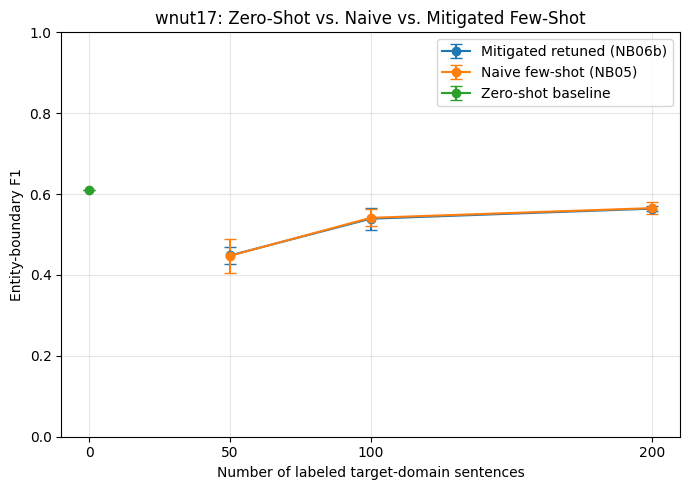

Saved: /content/drive/MyDrive/AAI590/data/processed/results/mitigated_retuned/wnut17_three_way_boundary_comparison.png


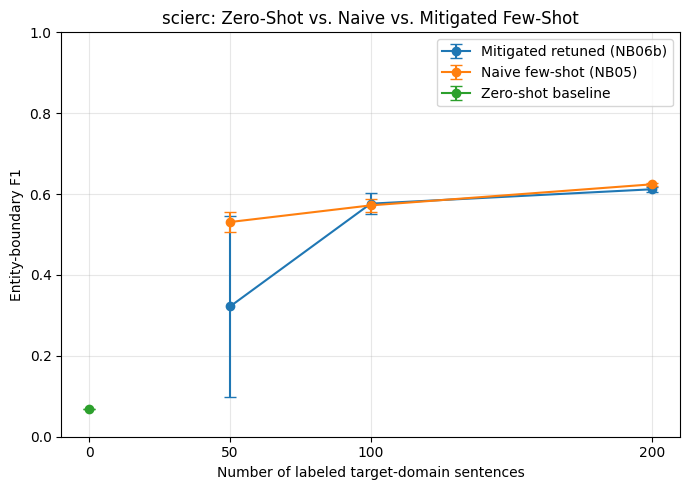

Saved: /content/drive/MyDrive/AAI590/data/processed/results/mitigated_retuned/scierc_three_way_boundary_comparison.png


In [11]:
for dataset_name in TARGET_DATASETS:
    plt.figure(figsize=(7, 5))

    for method, group in three_way_df[three_way_df["dataset"] == dataset_name].groupby("method"):
        group = group.sort_values("budget")
        plt.errorbar(
            group["budget"],
            group["boundary_f1_mean"],
            yerr=group["boundary_f1_std"].fillna(0),
            marker="o",
            capsize=4,
            label=method,
        )

    plt.xlabel("Number of labeled target-domain sentences")
    plt.ylabel("Entity-boundary F1")
    plt.title(f"{dataset_name}: Zero-Shot vs. Naive vs. Mitigated Few-Shot")
    all_budgets = sorted(three_way_df.loc[three_way_df["dataset"] == dataset_name, "budget"].unique())
    plt.xticks(all_budgets)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = MITIGATED_RESULTS_DIR / f"{dataset_name}_three_way_boundary_comparison.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


## Step 10 — Presentation-ready results table

In [12]:
presentation_rows = []

for dataset_name in TARGET_DATASETS:
    for method in ["Zero-shot baseline", "Naive few-shot (NB05)", "Mitigated retuned (NB06b)"]:
        subset = three_way_df[
            (three_way_df["dataset"] == dataset_name) &
            (three_way_df["method"] == method)
        ].sort_values("budget")

        for row in subset.itertuples():
            presentation_rows.append({
                "Dataset": dataset_name,
                "Method": method,
                "Budget": row.budget,
                "Boundary F1": f"{row.boundary_f1_mean:.3f} ± {0 if pd.isna(row.boundary_f1_std) else row.boundary_f1_std:.3f}",
            })

presentation_df = pd.DataFrame(presentation_rows)
presentation_path = MITIGATED_RESULTS_DIR / "presentation_three_way_table.csv"
presentation_df.to_csv(presentation_path, index=False)

display(presentation_df)
print("Saved:", presentation_path)


,Dataset,Method,Budget,Boundary F1
0,wnut17,Zero-shot baseline,0,0.610 ± 0.000
1,wnut17,Naive few-shot (NB05),50,0.447 ± 0.043
2,wnut17,Naive few-shot (NB05),100,0.541 ± 0.021
3,wnut17,Naive few-shot (NB05),200,0.565 ± 0.014
4,wnut17,Mitigated retuned (NB06b),50,0.448 ± 0.022
5,wnut17,Mitigated retuned (NB06b),100,0.539 ± 0.028
6,wnut17,Mitigated retuned (NB06b),200,0.564 ± 0.005
7,scierc,Zero-shot baseline,0,0.068 ± 0.000
8,scierc,Naive few-shot (NB05),50,0.531 ± 0.024
9,scierc,Naive few-shot (NB05),100,0.572 ± 0.016


Saved: /content/drive/MyDrive/AAI590/data/processed/results/mitigated_retuned/presentation_three_way_table.csv


## Step 11 — Final output inventory

The main files produced by this notebook are:

- `mitigated_results.csv` / `mitigated_results.json` — every individual mitigated run
- `mitigated_summary_by_budget.csv` — mean and standard deviation across seeds
- `three_way_boundary_comparison.csv` — zero-shot vs. naive (NB05) vs. mitigated (NB06)
- `presentation_three_way_table.csv` — compact table for the final presentation
- Three-way comparison plots for WNUT-17 and SciERC

**How to read the result:** if the mitigated WNUT-17 curve now sits at or above the 0.610
zero-shot line at budget 200 (and SciERC's gains from Notebook 05 are preserved), that
confirms catastrophic forgetting — not few-shot adaptation itself — was the cause of the
Notebook 05 regression, and this training recipe is the one worth carrying into the final
report. If WNUT-17 still lags zero-shot even here, that points to the data (few-shot sampling
skew from Notebook 02, or the inherent difficulty of WNUT-17's noisy/emerging entities) as the
next thing to investigate, rather than the training procedure.

In [13]:
print("Notebook 06 outputs:")
for path in sorted(MITIGATED_RESULTS_DIR.glob("*")):
    print(" -", path.name)


Notebook 06 outputs:
 - mitigated_results.csv
 - mitigated_results.json
 - mitigated_summary_by_budget.csv
 - presentation_three_way_table.csv
 - scierc_three_way_boundary_comparison.png
 - three_way_boundary_comparison.csv
 - wnut17_three_way_boundary_comparison.png
